In [16]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import gdown
import os

In [17]:
# url="https://drive.google.com/uc?id=1O2uCujErifjvK1ziRGssaQO9khI15g6q"
# gdown.download(url,None, quiet=True)

In [18]:
# ! unzip -qq /content/images.zip

In [19]:
# url="https://drive.google.com/uc?id=1I242ygNivRhYJ6kIEfvlAhg_2WMTgDDv"
# gdown.download(url,None, quiet=True)

In [20]:
# ! unzip -qq /content/SSDs.zip

In [23]:
! wget https://t4.ftcdn.net/jpg/03/12/95/13/360_F_312951336_8LxW7gBLHslTnpbOAwxFo5FpD2R5vGxu.jpg

--2025-04-04 13:15:51--  https://t4.ftcdn.net/jpg/03/12/95/13/360_F_312951336_8LxW7gBLHslTnpbOAwxFo5FpD2R5vGxu.jpg
Resolving t4.ftcdn.net (t4.ftcdn.net)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to t4.ftcdn.net (t4.ftcdn.net)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54619 (53K) [image/jpeg]
Saving to: ‘360_F_312951336_8LxW7gBLHslTnpbOAwxFo5FpD2R5vGxu.jpg’

360_F_312951336_8Lx 100%[===================>]  53.34K  --.-KB/s    in 0.01s   

2025-04-04 13:15:52 (3.68 MB/s) - ‘360_F_312951336_8LxW7gBLHslTnpbOAwxFo5FpD2R5vGxu.jpg’ saved [54619/54619]



In [24]:
! wget https://www.slashgear.com/img/gallery/5-of-the-fastest-motorcycles-kawasaki-ever-built/l-intro-1709052498.jpg

--2025-04-04 13:16:57--  https://www.slashgear.com/img/gallery/5-of-the-fastest-motorcycles-kawasaki-ever-built/l-intro-1709052498.jpg
Resolving www.slashgear.com (www.slashgear.com)... 3.166.181.79, 3.166.181.121, 3.166.181.108, ...
Connecting to www.slashgear.com (www.slashgear.com)|3.166.181.79|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 366548 (358K) [image/jpeg]
Saving to: ‘l-intro-1709052498.jpg’

l-intro-1709052498. 100%[===================>] 357.96K  --.-KB/s    in 0.09s   

2025-04-04 13:16:58 (3.96 MB/s) - ‘l-intro-1709052498.jpg’ saved [366548/366548]



In [26]:
! wget https://assets.surlatable.com/m/15a89c2d9c6c1345/72_dpi_webp-REC-283110_Pizza.jpg

--2025-04-04 13:18:42--  https://assets.surlatable.com/m/15a89c2d9c6c1345/72_dpi_webp-REC-283110_Pizza.jpg
Resolving assets.surlatable.com (assets.surlatable.com)... 13.35.116.118, 13.35.116.21, 13.35.116.74, ...
Connecting to assets.surlatable.com (assets.surlatable.com)|13.35.116.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 589476 (576K) [image/webp]
Saving to: ‘72_dpi_webp-REC-283110_Pizza.jpg’

72_dpi_webp-REC-283 100%[===================>] 575.66K  --.-KB/s    in 0.06s   

2025-04-04 13:18:42 (8.83 MB/s) - ‘72_dpi_webp-REC-283110_Pizza.jpg’ saved [589476/589476]



Successfully loaded 5 out of 5 images.
Running our Single Shot Detector on multiple images...


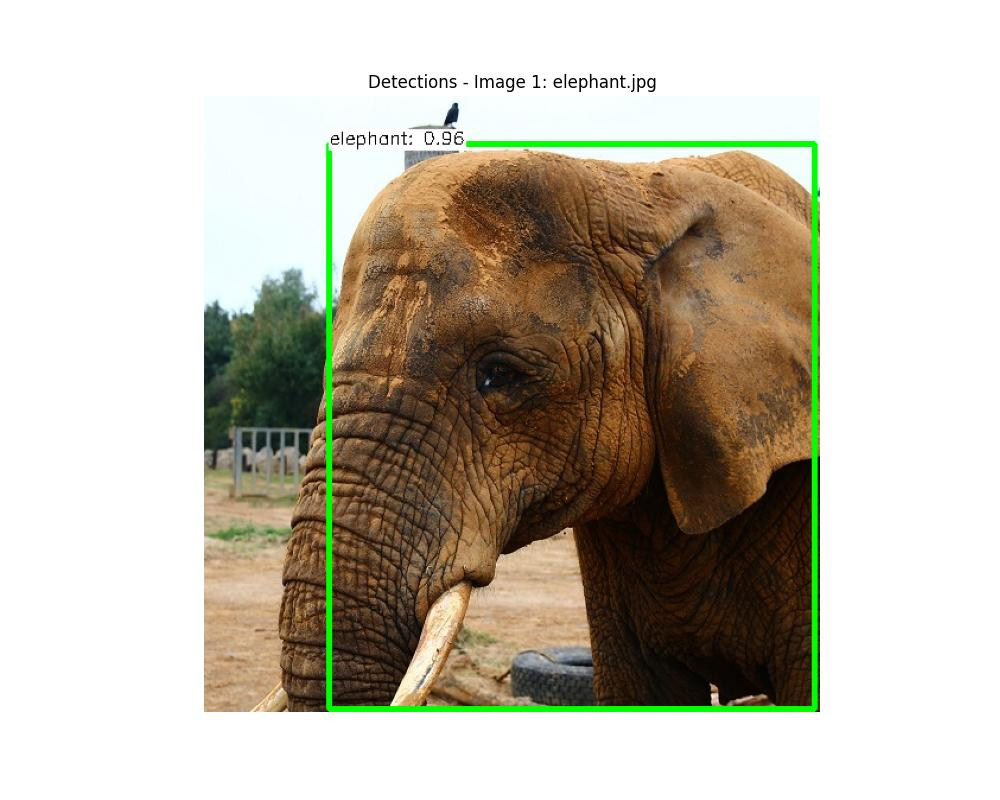

Processed image 1/5: elephant.jpg


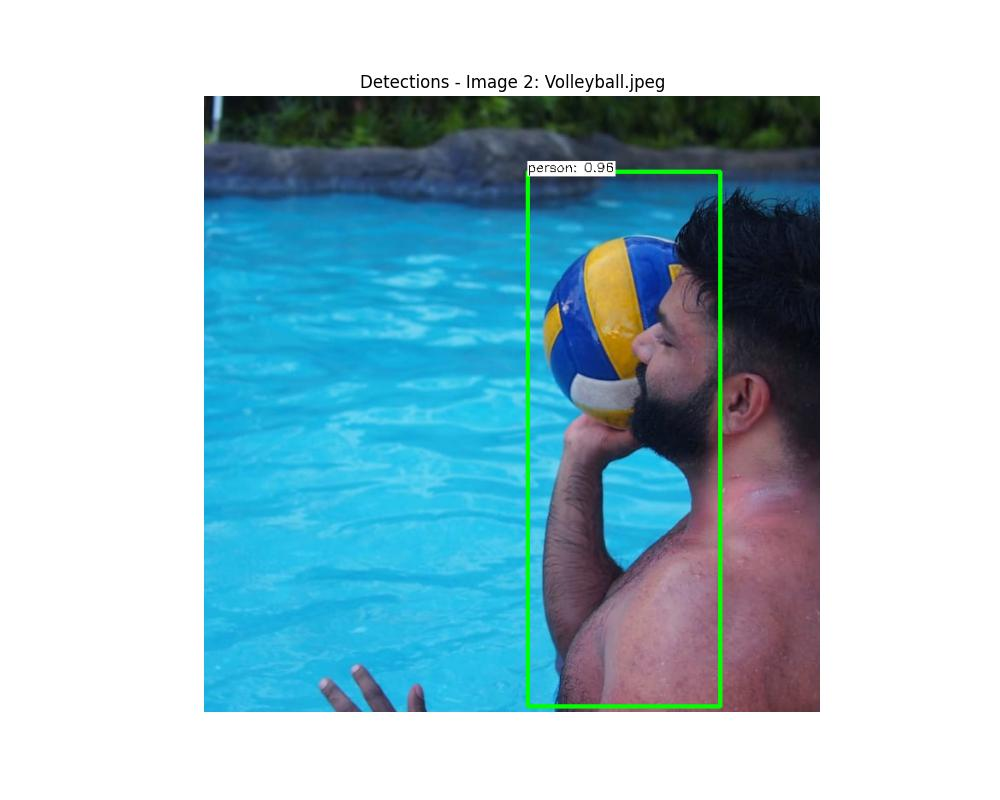

Processed image 2/5: Volleyball.jpeg


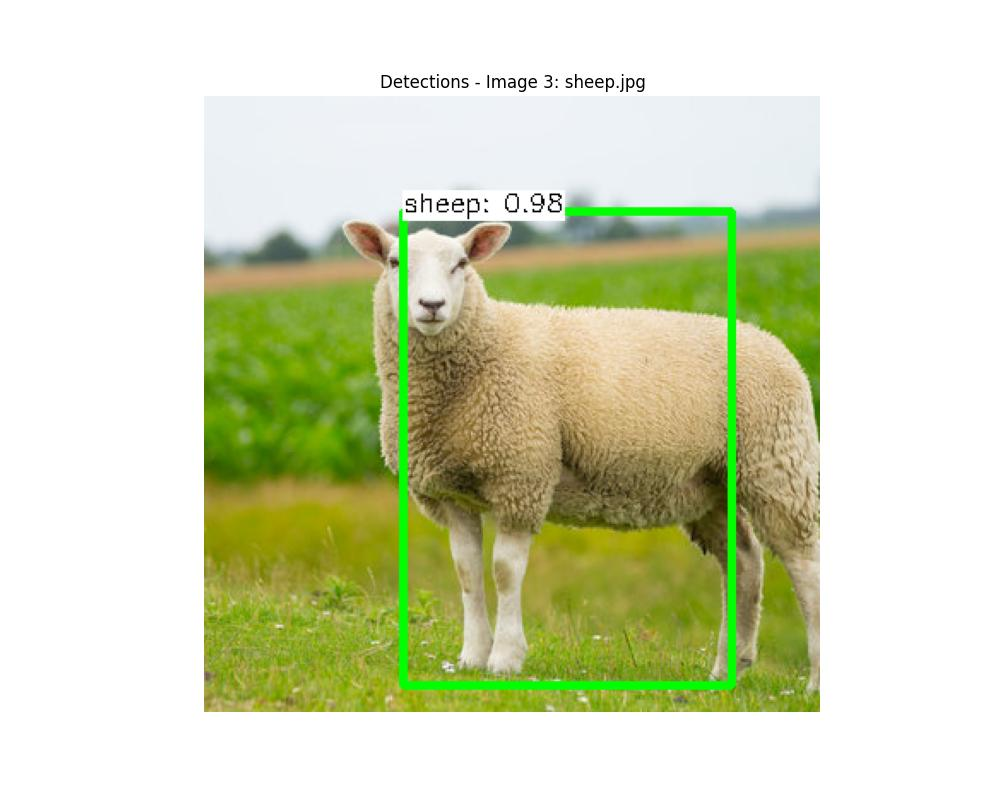

Processed image 3/5: sheep.jpg


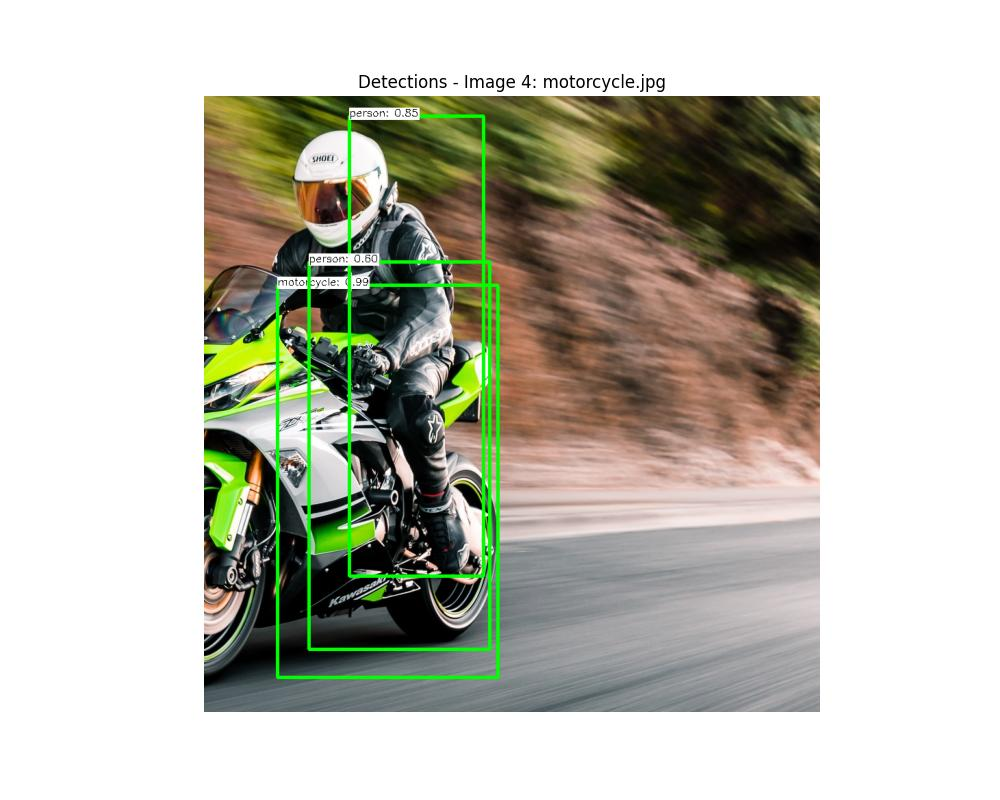

Processed image 4/5: motorcycle.jpg


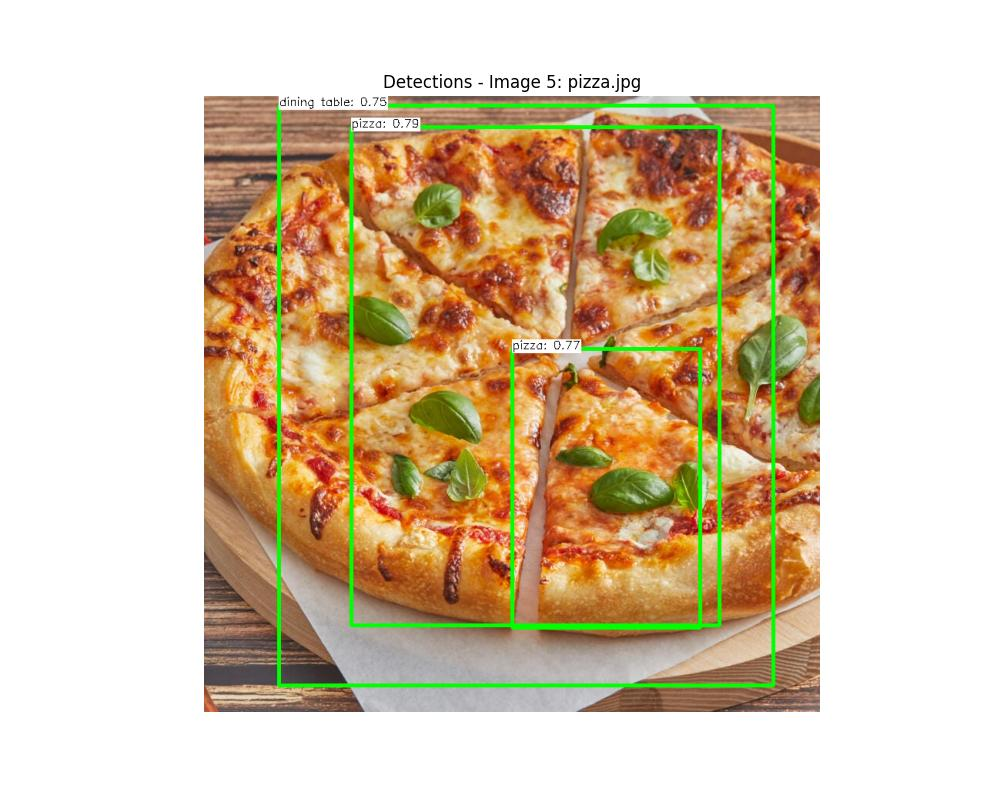

Processed image 5/5: pizza.jpg
Processing complete. All images have been processed and displayed/saved.


In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# List of image paths (all five images)
image_paths = [
    "/content/images/elephant.jpg",
    "/content/images/Volleyball.jpeg",
    "/content/sheep.jpg",
    "/content/motorcycle.jpg",
    "/content/pizza.jpg"
]

# Load all images into a list and immediately check which ones were loaded successfully
frames = []
valid_paths = []

for i, path in enumerate(image_paths):
    img = cv2.imread(path)
    if img is not None:
        frames.append(img)
        valid_paths.append(path)
    else:
        print(f"Warning: Could not load image {i+1}: {path}")

if not frames:
    print("Error: No images loaded successfully.")
    exit()

print(f"Successfully loaded {len(frames)} out of {len(image_paths)} images.")
print("Running our Single Shot Detector on multiple images...")

# Set the widths and heights needed for input into our model
inWidth = 300
inHeight = 300
WHRatio = inWidth / float(inHeight)

# Preprocessing parameters
inScaleFactor = 0.007843
meanVal = 127.5

# Paths to the model weights and architecture
prototxt = "/content/SSDs/ssd_mobilenet_v1_coco.pbtxt"
weights = "/content/SSDs/frozen_inference_graph.pb"

# Number of classes and probability threshold
num_classes = 90
thr = 0.5

# Load the SSD model
net = cv2.dnn.readNetFromTensorflow(weights, prototxt)

# Class names dictionary
classNames = {
    0: 'background', 1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle',
    5: 'airplane', 6: 'bus', 7: 'train', 8: 'truck', 9: 'boat',
    10: 'traffic light', 11: 'fire hydrant', 13: 'stop sign',
    14: 'parking meter', 15: 'bench', 16: 'bird', 17: 'cat',
    18: 'dog', 19: 'horse', 20: 'sheep', 21: 'cow', 22: 'elephant',
    23: 'bear', 24: 'zebra', 25: 'giraffe', 27: 'backpack', 28: 'umbrella',
    31: 'handbag', 32: 'tie', 33: 'suitcase', 34: 'frisbee', 35: 'skis',
    36: 'snowboard', 37: 'sports ball', 38: 'kite', 39: 'baseball bat',
    40: 'baseball glove', 41: 'skateboard', 42: 'surfboard', 43: 'tennis racket',
    44: 'bottle', 46: 'wine glass', 47: 'cup', 48: 'fork', 49: 'knife',
    50: 'spoon', 51: 'bowl', 52: 'banana', 53: 'apple', 54: 'sandwich',
    55: 'orange', 56: 'broccoli', 57: 'carrot', 58: 'hot dog', 59: 'pizza',
    60: 'donut', 61: 'cake', 62: 'chair', 63: 'couch', 64: 'potted plant',
    65: 'bed', 67: 'dining table', 70: 'toilet', 72: 'tv', 73: 'laptop',
    74: 'mouse', 75: 'remote', 76: 'keyboard', 77: 'cell phone', 78: 'microwave',
    79: 'oven', 80: 'toaster', 81: 'sink', 82: 'refrigerator', 84: 'book',
    85: 'clock', 86: 'vase', 87: 'scissors', 88: 'teddy bear', 89: 'hair drier',
    90: 'toothbrush'
}

# Create separate figures for each image
for idx, frame in enumerate(frames):
    # Make a copy of the loaded image
    image = frame.copy()

    # Create input blob for the network
    blob = cv2.dnn.blobFromImage(image, inScaleFactor, (inWidth, inHeight), (meanVal, meanVal, meanVal), swapRB=True)
    net.setInput(blob)

    # Forward pass through the network
    detections = net.forward()

    # Crop frame if needed (square input)
    cols = frame.shape[1]
    rows = frame.shape[0]

    if cols / float(rows) > WHRatio:
        cropSize = (int(rows * WHRatio), rows)
    else:
        cropSize = (cols, int(cols / WHRatio))

    y1 = int((rows - cropSize[1]) / 2)
    y2 = y1 + cropSize[1]
    x1 = int((cols - cropSize[0]) / 2)
    x2 = x1 + cropSize[0]
    frame = frame[y1:y2, x1:x2]

    cols = frame.shape[1]
    rows = frame.shape[0]

    # Iterate over detections
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > thr:
            class_id = int(detections[0, 0, i, 1])

            xLeftBottom = int(detections[0, 0, i, 3] * cols)
            yLeftBottom = int(detections[0, 0, i, 4] * rows)
            xRightTop = int(detections[0, 0, i, 5] * cols)
            yRightTop = int(detections[0, 0, i, 6] * rows)

            # Draw bounding box
            cv2.rectangle(frame, (xLeftBottom, yLeftBottom), (xRightTop, yRightTop), (0, 255, 0), 3)

            # Add label if class exists
            if class_id in classNames:
                label = f"{classNames[class_id]}: {confidence:.2f}"
                labelSize, baseLine = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)

                yLeftBottom = max(yLeftBottom, labelSize[1])
                cv2.rectangle(frame, (xLeftBottom, yLeftBottom - labelSize[1]),
                              (xLeftBottom + labelSize[0], yLeftBottom + baseLine),
                              (255, 255, 255), cv2.FILLED)
                cv2.putText(frame, label, (xLeftBottom, yLeftBottom),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0))

    # Convert BGR to RGB for matplotlib display
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Create a new figure for each image
    plt.figure(figsize=(10, 8))
    plt.imshow(frame_rgb)
    plt.title(f"Detections - Image {idx + 1}: {valid_paths[idx].split('/')[-1]}")
    plt.axis('off')

    # Instead of plt.show(), which blocks execution until the figure is closed
    # Use plt.savefig() to save the image, then display it
    save_path = f"/content/detection_result_{idx+1}.jpg"
    plt.savefig(save_path)

    # For Google Colab, use the display function that doesn't block execution
    try:
        from IPython.display import display, Image
        display(Image(filename=save_path))
    except ImportError:
        # If not in an IPython/Colab environment, just show the plot
        plt.show(block=False)  # non-blocking show

    plt.close()  # Close the figure to free memory

    print(f"Processed image {idx + 1}/{len(frames)}: {valid_paths[idx].split('/')[-1]}")

print("Processing complete. All images have been processed and displayed/saved.")